In [8]:
import pandas as pd

df = pd.read_parquet("C:/Users/rushabh/Desktop/threat-hunting-project/DDoS-Friday-no-metadata.parquet", engine='fastparquet')
df.to_csv("C:/Users/rushabh/Desktop/threat-hunting-project/DDoS-Friday.csv", index=False)
print("Done! CSV created.")
print(df.shape)

Done! CSV created.
(221264, 78)


In [9]:
# See all column names
print(df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [10]:
# See how many attacks vs normal traffic we have
print(df['Label'].value_counts())

Label
DDoS      128014
Benign     93250
Name: count, dtype: int64


In [11]:
# Compare DDoS vs Benign traffic
df.groupby('Label')[['Flow Packets/s', 'Flow Duration', 'Flow Bytes/s']].mean()

,Flow Packets/s,Flow Duration,Flow Bytes/s
Label,,,
Benign,19023.014039,1.603962e+07,565248.370013
DDoS,155.388791,1.695716e+07,60509.888920


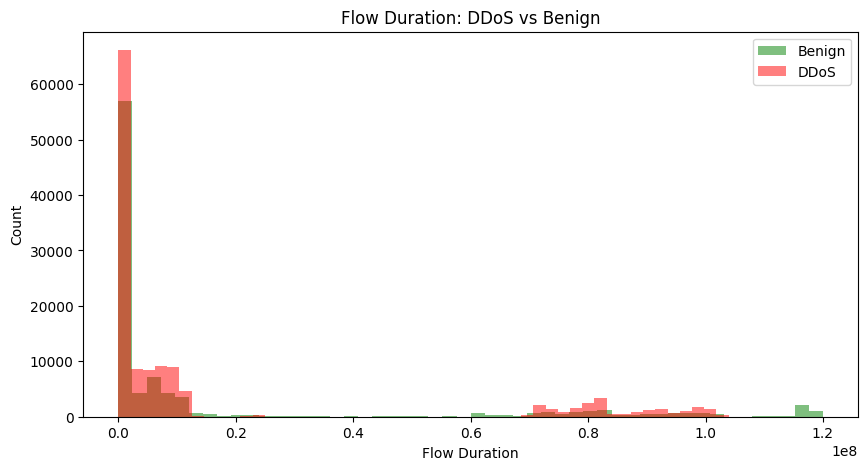

In [12]:
import matplotlib.pyplot as plt

# Plot Flow Duration for DDoS vs Benign
ddos = df[df['Label'] == 'DDoS']['Flow Duration']
benign = df[df['Label'] == 'Benign']['Flow Duration']

plt.figure(figsize=(10,5))
plt.hist(benign, bins=50, alpha=0.5, label='Benign', color='green')
plt.hist(ddos, bins=50, alpha=0.5, label='DDoS', color='red')
plt.xlabel('Flow Duration')
plt.ylabel('Count')
plt.title('Flow Duration: DDoS vs Benign')
plt.legend()
plt.show()

In [1]:
# Check top features that differ between DDoS and Benign
df.groupby('Label')[['Flow Duration', 'SYN Flag Count', 'Flow Bytes/s', 'Packet Length Mean']].mean()

NameError: name 'df' is not defined

In [2]:
No worries! This happens because Jupyter lost the data when you closed it. We just need to reload it.

Run this first:

```python
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/rushabh/Desktop/threat-hunting-project/DDoS-Friday.csv")
print("Data loaded! Shape:", df.shape)
```

Once it prints the shape, then run the next cell! 🚀

SyntaxError: invalid character '🚀' (U+1F680) (1737403551.py, line 13)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/rushabh/Desktop/threat-hunting-project/DDoS-Friday.csv")
print("Data loaded! Shape:", df.shape)

Data loaded! Shape: (221264, 78)


In [4]:
# Check top features that differ between DDoS and Benign
df.groupby('Label')[['Flow Duration', 'SYN Flag Count', 'Flow Bytes/s', 'Packet Length Mean']].mean()

,Flow Duration,SYN Flag Count,Flow Bytes/s,Packet Length Mean
Label,,,,
Benign,1.603962e+07,0.073952,565248.370013,233.063630
DDoS,1.695716e+07,0.000000,60509.888920,736.948805


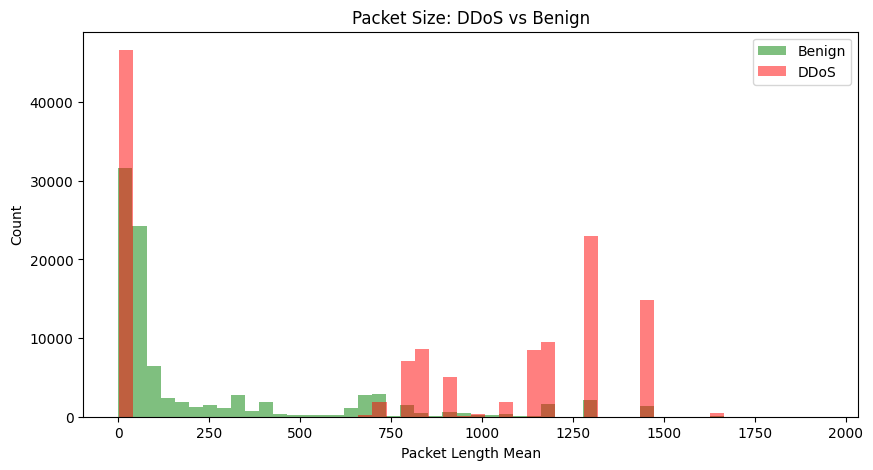

In [5]:
plt.figure(figsize=(10,5))
ddos = df[df['Label'] == 'DDoS']['Packet Length Mean']
benign = df[df['Label'] == 'Benign']['Packet Length Mean']

plt.hist(benign, bins=50, alpha=0.5, label='Benign', color='green')
plt.hist(ddos, bins=50, alpha=0.5, label='DDoS', color='red')
plt.xlabel('Packet Length Mean')
plt.ylabel('Count')
plt.title('Packet Size: DDoS vs Benign')
plt.legend()
plt.show()

In [6]:
# Check Dash is working
import dash
print(dash.__version__)

4.1.0
